In [7]:
from utils import SphericalWaveAnalytic, ExtractResultOnDefinedAxis
import sys
sys.path.append("../../../../../share/python/")
from postprocess_25d import PostProcessHarmonic25d
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
freq = 100 # 100 Hz
pos = np.linspace(0,5,21) # 0 to 5 m in z direction
file = 'AcousticHarmonic25D.h5ref'
#file = 'results_hdf5/AcousticHarmonic25D.cfs'
PostProcessHarmonic25d(file_name=file, copy_file_name="AcousticHarmonic25D_postprocessed.cfs", pos_list=pos, create_copy=True)
shift_point_desired = [1.5,0]
z,coord,result = ExtractResultOnDefinedAxis(hdf_name='AcousticHarmonic25D_postprocessed.cfs',result='acouPressure', region="S_channel",step='all',multistep=2,dim='2.5d',axis='z',ShiftCoord=shift_point_desired)
shift_point_actual = coord[0,0:2]
print(shift_point_desired,shift_point_actual)

[1.5, 0] [1.42916667 0.        ]


In [9]:
x,result_x = ExtractResultOnDefinedAxis(hdf_name='AcousticHarmonic25D_postprocessed.cfs',result='acouPressure', region="S_channel",step=1,multistep=2,dim='2.5d',axis='x')
_, result_x_analytic = SphericalWaveAnalytic(rhsValue=1,freq=freq, r=x, sphere='fourth')

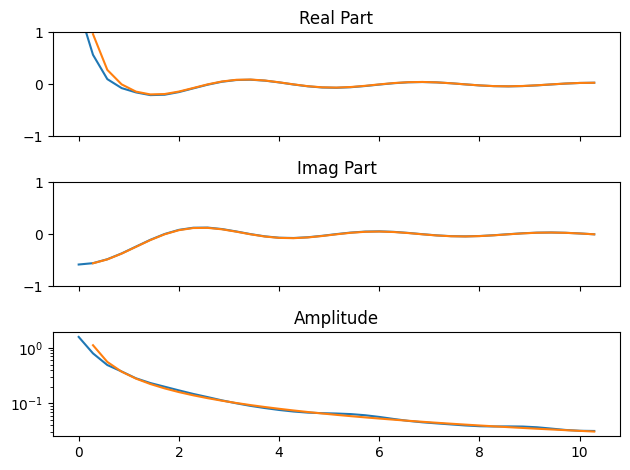

In [10]:
fig, ax = plt.subplots(nrows=3,ncols=1,sharex=True)

ax[0].plot(x,result_x.real)
ax[0].plot(x,result_x_analytic.real)
ax[0].set_ylim(-1,1)
ax[0].set_title("Real Part")
ax[1].plot(x,result_x.imag)
ax[1].plot(x,result_x_analytic.imag)
ax[1].set_ylim(-1,1)
ax[1].set_title("Imag Part")
ax[2].plot(x,np.abs(result_x),label='2.5D solution')
ax[2].plot(x,np.abs(result_x_analytic),label='analytic solution')
ax[2].set_yscale("log")
ax[2].set_title("Amplitude")
plt.tight_layout()
plt.show()

In [11]:
_, result_analytic = SphericalWaveAnalytic(rhsValue=1,freq=freq, r=coord, sphere='fourth')

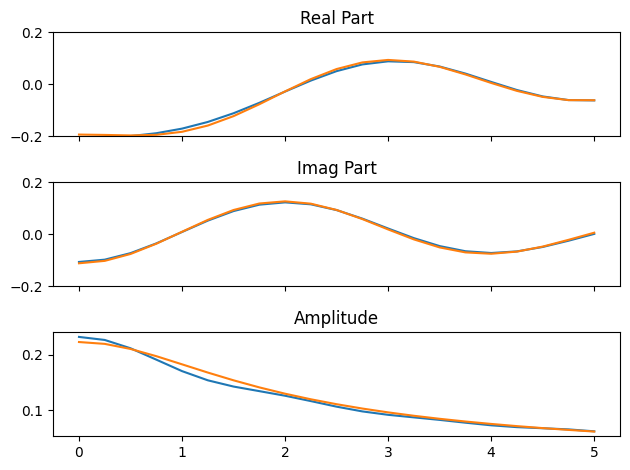

In [12]:
fig, ax = plt.subplots(nrows=3,ncols=1,sharex=True)

ax[0].plot(z,result.real)
ax[0].plot(z,result_analytic.real)
ax[0].set_ylim(-0.2,0.2)
ax[0].set_title("Real Part")
ax[1].plot(z,result.imag)
ax[1].plot(z,result_analytic.imag)
ax[1].set_ylim(-0.2,0.2)
ax[1].set_title("Imag Part")
ax[2].plot(z,np.abs(result),label='2.5D solution')
ax[2].plot(z,np.abs(result_analytic),label='analytic solution')
#ax[2].set_yscale("log")
ax[2].set_title("Amplitude")
plt.tight_layout()
plt.show()